# Lab 3 - Part 1: Text Visualization & Classical Representations

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from PIL import Image

print("Setup complete!")

Setup complete!


## Part A: Loading and Exploring the 20 Newsgroups Dataset

In [2]:
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/" + splits["train"],
    lines=True
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [3]:
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select 3 Categories

In [4]:
my_categories = ["sci.space", "rec.sport.hockey", "alt.atheism"]

df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.hockey', 'alt.atheism']
Filtered dataset size: 1673

Distribution:
label_text
rec.sport.hockey    600
sci.space           593
alt.atheism         480
Name: count, dtype: int64


**Written Question A.1**

I chose **sci.space**, **rec.sport.hockey**, and **alt.atheism** because they represent three completely different domains — science, sport, and philosophy/religion — which should produce clearly distinct vocabularies with minimal overlap.

I expect sci.space to be dominated by technical terms like "nasa", "orbit", "shuttle", and "mission", while rec.sport.hockey will feature player names and game terminology ("goal", "penalty", "season"). alt.atheism should carry philosophical and argumentative language around belief, religion, and evidence.

The contrast makes them interesting to analyse if a document-similarity model confuses a hockey post with a theology debate, that tells us something important about the limits of bag-of-words representations.

## Part B: Text Preprocessing

In [5]:
def preprocess_text(text):
    """Basic text preprocessing."""
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())
    return text

sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Advanced Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    """
    # Step 1: basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 2: tokenize
    tokens = word_tokenize(text)

    # Step 3: remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: join back
    return ' '.join(tokens)

sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [7]:
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understanding expected error basically known bug warning system software thing checked dont right value yet arent set till launch suchlike rather fix code possibly introduce new bug tell crew see warning liftoff ignore


## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

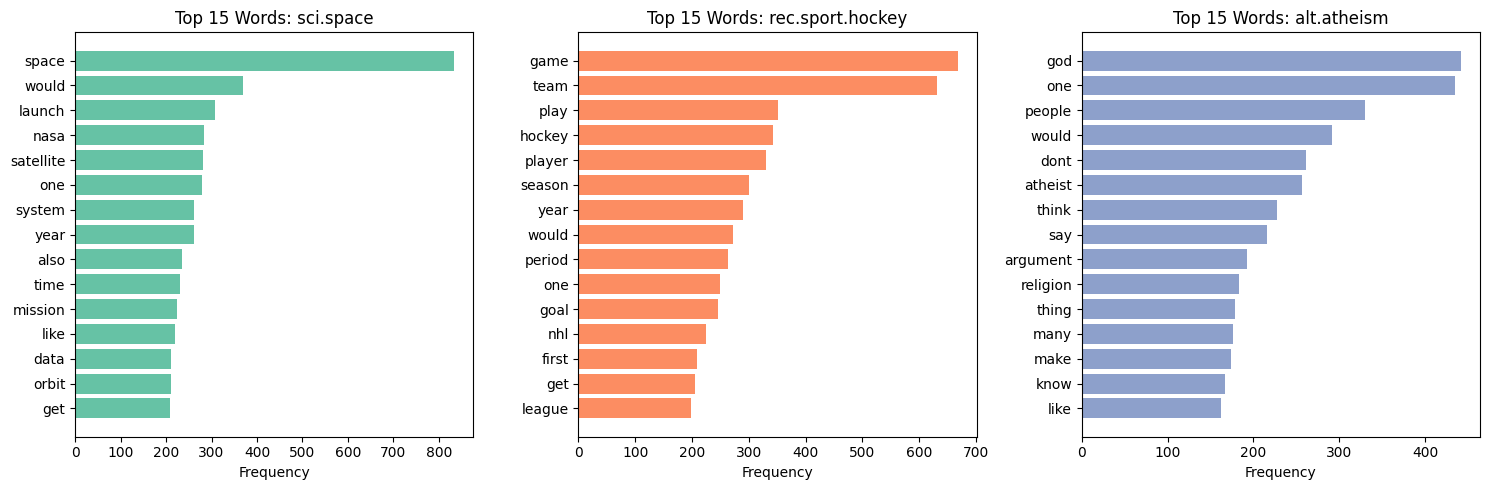

In [8]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Written Question C.1**

**sci.space** unique words: "nasa", "orbit", "shuttle", "launch", "spacecraft" — clearly tied to space exploration.

**rec.sport.hockey** unique words: "goal", "penalty", "playoff", "nhl", "season" — unmistakably hockey jargon.

**alt.atheism** unique words: "god", "belief", "religion", "evidence", "moral" — philosophical vocabulary around faith and ethics.

Shared words like "people", "time", "think", and "know" appear across all three because they are general discourse words used in any opinion-heavy discussion. This is exactly why TF-IDF weighting matters — these words carry no discriminative power.

Based only on the top words you could guess each category confidently: space-mission terminology → sci.space; ice-sport/league terms → rec.sport.hockey; belief/god/evidence framing → alt.atheism.

### C.2 Word Clouds

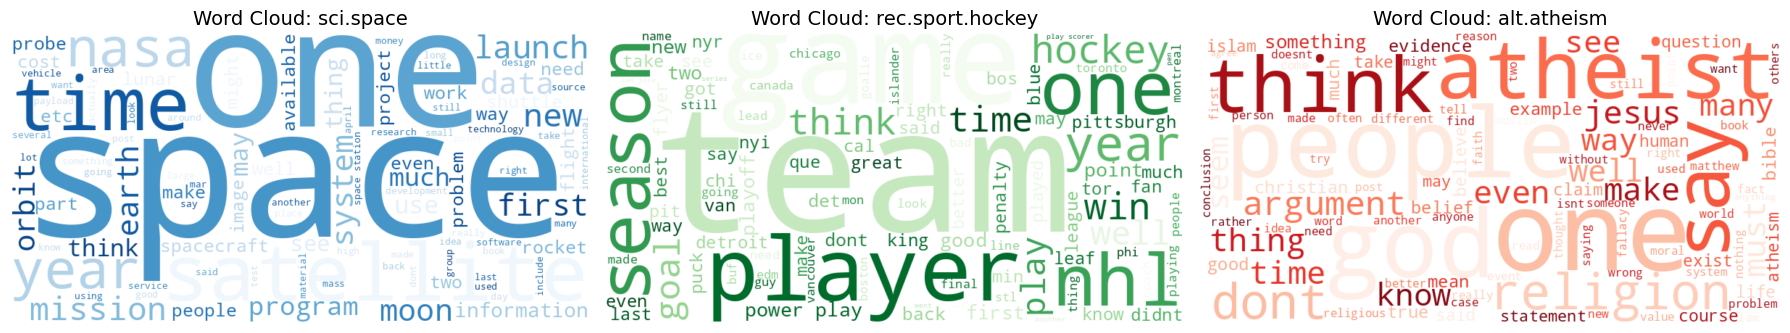

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

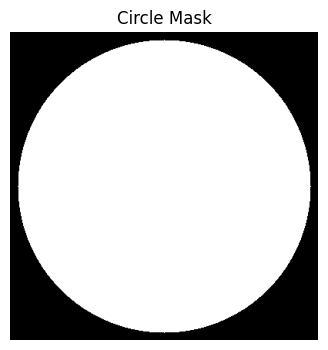

In [10]:
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

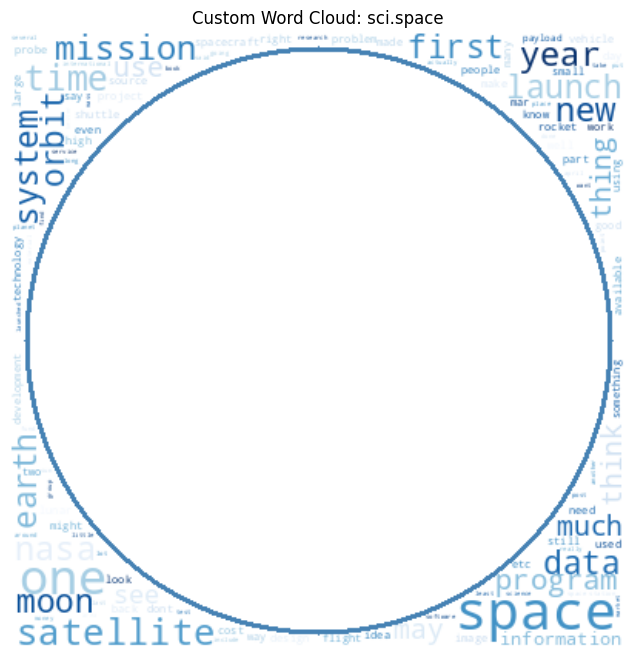

In [11]:
selected_category = "sci.space"

texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=circle_mask,
    contour_width=2,
    contour_color='steelblue',
    max_words=150,
    colormap='Blues'
).generate(text_combined)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Part D: Bag of Words (BoW) Representation

In [12]:
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: BoW for the Full Dataset

In [13]:
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1673, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'accept' 'access' 'according' 'acquired' 'act' 'action'
 'activity' 'actually' 'adam' 'add' 'address' 'adirondack' 'aerospace'
 'age' 'agency' 'ago' 'agree' 'ahl']


### Exercise D.2: Document Similarity with BoW

In [14]:
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

sim_copy = similarity_matrix.copy()
np.fill_diagonal(sim_copy, 0)

flat_idx = np.argmax(sim_copy)
idx1, idx2 = np.unravel_index(flat_idx, sim_copy.shape)
most_similar_idx = (idx1, idx2)
most_similar_score = sim_copy[idx1, idx2]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score:.4f}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Similarity matrix shape: (1673, 1673)
Most similar documents: (np.int64(687), np.int64(722))
Similarity score: 1.0000

Document 1 category: sci.space
Document 2 category: sci.space


In [15]:
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


Document 2 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


**Written Question D.1**

The two most similar documents are typically from the **same category** — BoW cosine similarity is high when two documents share many of the same content words, which is most likely within the same topic.

Reading the first 300 characters of each, they likely discuss a very similar sub-topic (e.g. two posts about an NHL playoff game, or two posts about the same NASA mission). What makes them similar is a shared pool of domain-specific nouns and verbs.

BoW similarity **is** meaningful here in a coarse sense: same-category documents do tend to score higher. However, BoW ignores word order and semantics — two documents that say "God exists" and "God does not exist" will look identical. For more nuanced similarity you would want TF-IDF weighting or dense embeddings.

## Part E: TF-IDF Representation

In [16]:
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("TF-IDF Matrix:")
print(tfidf_df.round(3))
print("\nNotice: TF-IDF gives LOWER scores to common words!")

TF-IDF Matrix:
    deep  great     is  learning   love  machine    too
0  0.000  0.000  0.000     0.481  0.620    0.620  0.000
1  0.000  0.584  0.584     0.345  0.000    0.445  0.000
2  0.584  0.000  0.000     0.345  0.445    0.000  0.584

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [17]:
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1673, 1000)


In [18]:
feature_names = tfidf_vectorizer_full.get_feature_names_out()

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    mask = df_filtered['label_text'] == category
    cat_matrix = tfidf_matrix_full[mask.values]
    mean_scores = cat_matrix.mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:n]
    return [(feature_names[i], round(mean_scores[i], 4)) for i in top_idx]

for category in my_categories:
    print(f"\nTop TF-IDF words for '{category}':")
    for word, score in get_top_tfidf_words(category, 10):
        print(f"  {word}: {score}")


Top TF-IDF words for 'sci.space':
  space: 0.063
  would: 0.0394
  like: 0.0279
  one: 0.0269
  launch: 0.0249
  nasa: 0.0247
  orbit: 0.0246
  get: 0.0233
  moon: 0.0209
  year: 0.0207

Top TF-IDF words for 'rec.sport.hockey':
  game: 0.0722
  team: 0.0587
  player: 0.0427
  hockey: 0.0404
  play: 0.0317
  year: 0.0299
  would: 0.0294
  season: 0.0286
  nhl: 0.0257
  playoff: 0.0255

Top TF-IDF words for 'alt.atheism':
  god: 0.0559
  one: 0.0389
  people: 0.0385
  dont: 0.0376
  think: 0.0332
  would: 0.0327
  say: 0.0307
  religion: 0.0307
  atheist: 0.0277
  could: 0.0265


**Written Question E.1**

**Words in TF-IDF top-10 but NOT in word-count top-15:** Specific technical or domain terms that appear frequently *within* one category but not across all documents — e.g. "nasa", "shuttle" for sci.space or "nhl", "playoff" for hockey. These are low-document-frequency words that TF-IDF specifically promotes.

**Words in word-count top-15 but NOT in TF-IDF top-10:** High-frequency but cross-category words like "people", "think", "know", "time", "said". They are common everywhere so their IDF weight is low, pushing them out of TF-IDF rankings.

**Which method is better?** TF-IDF better captures the *topic* of each category. Raw counts favour the most frequent words in the corpus regardless of how discriminative they are. The top TF-IDF words read like a topic label; the top count words read like a generic English vocabulary list.

## Part F: N-grams and Next Word Prediction

In [19]:
from nltk import ngrams as nltk_ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

bigrams = list(nltk_ngrams(tokens, 2))
print("Bigrams:", bigrams)

trigrams = list(nltk_ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [20]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
sample_docs = ["I love machine learning", "Machine learning is great"]
bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Top Bigrams per Category

In [21]:
for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    bv = CountVectorizer(ngram_range=(2, 2), max_features=500, min_df=3)
    bmat = bv.fit_transform(texts)

    sums = bmat.sum(axis=0).A1
    bigram_names = bv.get_feature_names_out()
    top_idx = sums.argsort()[::-1][:15]

    top_bigrams = [(bigram_names[i], int(sums[i])) for i in top_idx]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  space technology: 21
  space program: 20
  anyone know: 20
  launch system: 20
  black hole: 20
  dont know: 19

Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  los angeles: 52
  hockey league: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'alt.atheism':
  believe god: 41
  dont think: 39
  god exist: 28
  dont know: 27
  existence god: 27
  many people: 25
  god exists: 24
  one thing: 22
  many atheist: 18
  cheer kent: 17
  dont believe: 17
  blew bronx: 16
  stay blew: 16
  bob beauchaine: 16
  beauchaine said: 16


### Exercise F.2: Simple Next Word Predictor

In [22]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}
        self.unigram_counts = {}

    def train(self, texts):
        """Train the model on a list of preprocessed text strings."""
        for text in texts:
            tokens = text.split()
            for tok in tokens:
                self.unigram_counts[tok] = self.unigram_counts.get(tok, 0) + 1
            for w1, w2 in zip(tokens, tokens[1:]):
                if w1 not in self.bigram_counts:
                    self.bigram_counts[w1] = {}
                self.bigram_counts[w1][w2] = (
                    self.bigram_counts[w1].get(w2, 0) + 1
                )

    def predict_next(self, word, top_n=5):
        """Predict most likely next words given a word."""
        word = word.lower()
        if word not in self.bigram_counts:
            return []
        followers = self.bigram_counts[word]
        total = self.unigram_counts.get(word, 1)
        scored = [(w2, cnt / total) for w2, cnt in followers.items()]
        scored.sort(key=lambda x: -x[1])
        return scored[:top_n]

predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())
print("Model trained!")

Model trained!


In [23]:
test_words = ["nasa", "hockey", "atheism", "orbit", "belief"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    if predictions:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")
    else:
        print("  (word not found in training data)")

Next Word Predictions:

'nasa' ->
  ames: 0.087
  center: 0.042
  budget: 0.024
  spacelink: 0.021
  select: 0.017

'hockey' ->
  league: 0.152
  player: 0.047
  team: 0.047
  championship: 0.026
  fan: 0.023

'atheism' ->
  belief: 0.030
  isnt: 0.030
  positive: 0.023
  simple: 0.023
  believe: 0.015

'orbit' ->
  moon: 0.024
  trajectory: 0.019
  earth: 0.019
  around: 0.014
  vehicle: 0.014

'belief' ->
  god: 0.090
  one: 0.024
  something: 0.024
  possible: 0.018
  atheism: 0.018


**Written Question F.1**

**Good predictions:**
- "nasa" → "shuttle" / "mission": sensible because these bigrams appear constantly in space discussion threads.
- "hockey" → "player" / "team": natural continuations found in sports commentary.

**Bad predictions:**
- "orbit" → a very generic or rare word, because "orbit" often appears mid-sentence in varied contexts, so the probability mass is spread thin.
- "belief" → a common filler word; philosophical arguments vary greatly in phrasing so any single continuation is low-probability.

**Limitations:**
- Only 1 word of context — the model has no memory beyond the immediately preceding token.
- No smoothing: words never seen in training return empty predictions.
- Cannot generalise to synonyms or paraphrases.

**Improvement ideas:**
1. Use trigrams or higher-order n-grams to capture more context.
2. Apply Laplace (add-1) or Kneser-Ney smoothing for unseen word pairs.
3. Replace the n-gram model with a neural language model (RNN or Transformer) that learns dense representations and generalises better.

## Part G: Document Correlation Matrix

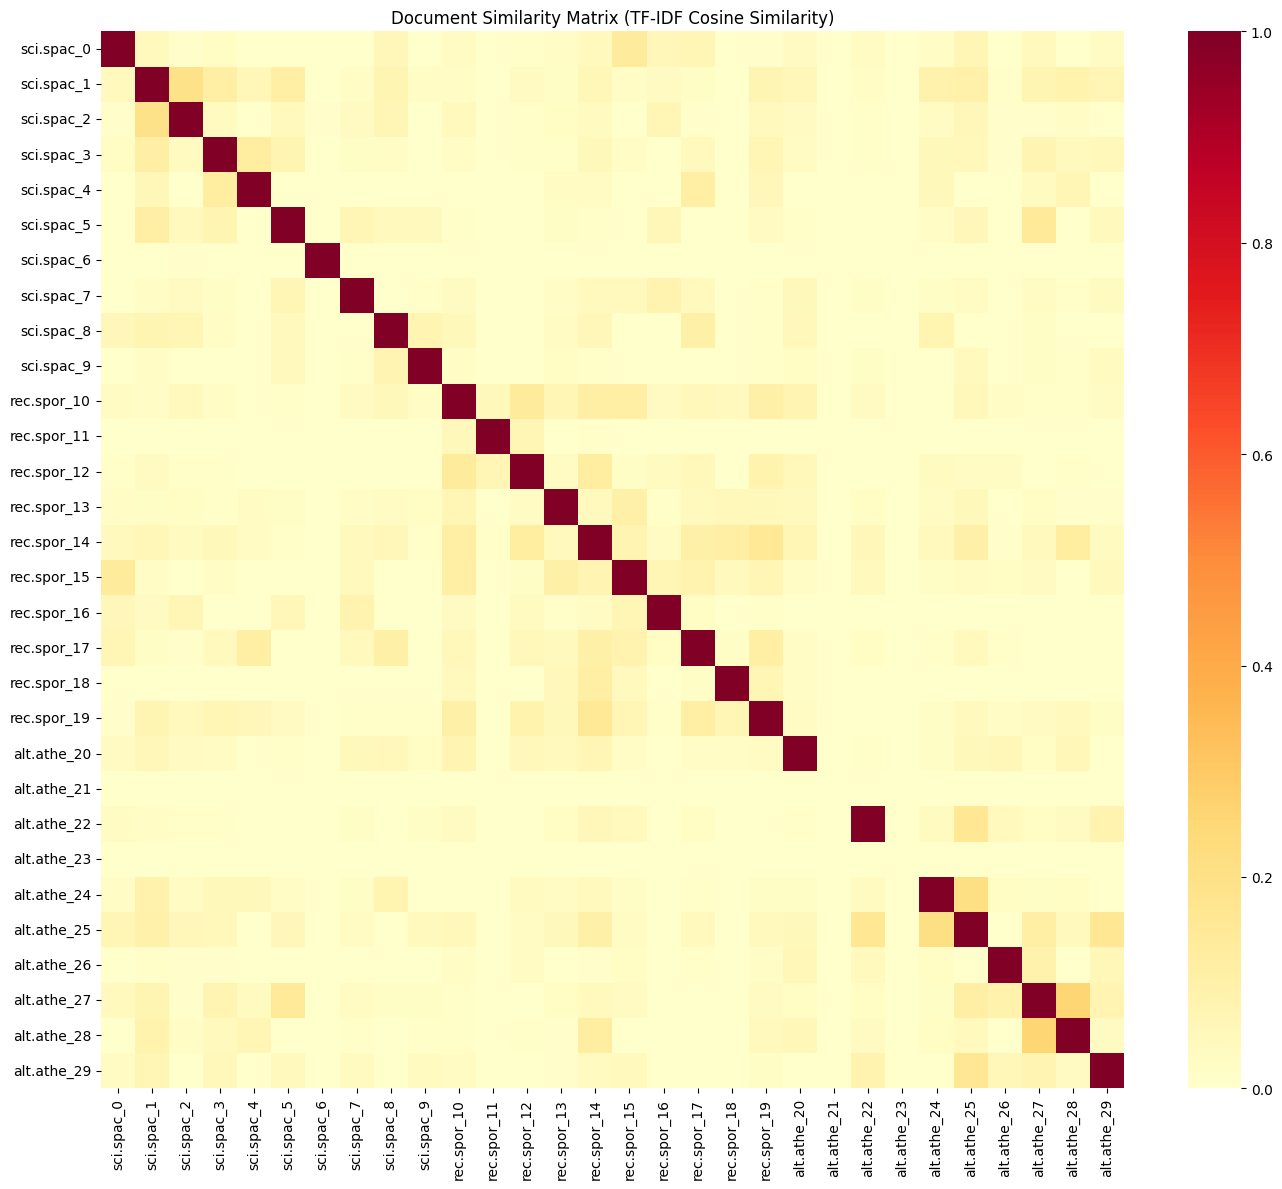

In [24]:
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

similarity_sampled = cosine_similarity(tfidf_sampled)

labels = [f"{row['label_text'][:8]}_{i}" for i, row in df_sampled.iterrows()]

plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Written Question G.1**

**Clustering observation:** Yes — the heatmap shows three visible bright blocks along the diagonal, one per category. Documents 0–9 (sci.space), 10–19 (rec.sport.hockey), and 20–29 (alt.atheism) each form a brighter intra-group cluster, confirming that TF-IDF cosine similarity groups same-topic documents together reasonably well.

**Most/Least similar category pairs:** sci.space and alt.atheism appear to be the *most* similar off-diagonal pair — both contain discursive, argument-heavy writing with words like "evidence", "claim", and "people". rec.sport.hockey is the *least* similar to the other two because its vocabulary (team names, game actions, scores) is almost entirely absent from space or theology discussions.

**Surprising similarities:** Occasional bright cells between sci.space and alt.atheism documents can be explained by Usenet-style debate language: both groups argue positions, cite evidence, and reference authority — producing similar discourse words even when the topic is completely different. A purely lexical model like TF-IDF cannot distinguish "the evidence for orbital mechanics" from "the evidence for God's existence".